1.25e-06 0
6


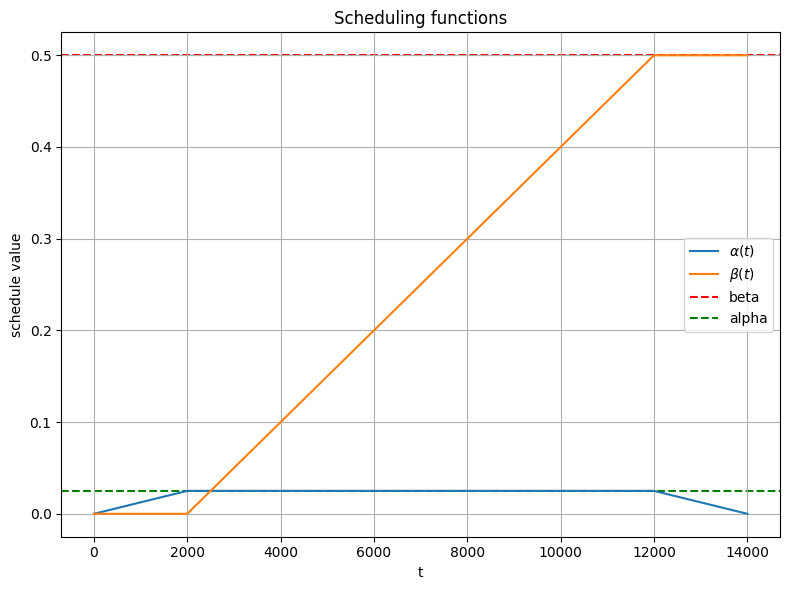

In [1]:
import numpy as np
import scipy as sp
import matplotlib
import itertools
import joblib
import matplotlib.pyplot as plt
import tqdm 
from adiabatic_computation.hamiltonian import H_B, H_P, H_D
from adiabatic_computation.schrodinger import schrodinger_split
from adiabatic_computation import X

n = 2
steps = 300
beta_max = 1/n
alpha_max = 0.05/n
T_pen = 10000
T_x = T_pen/5
T_f = 2*T_x + T_pen
Ts = np.linspace(0.1, T_f, steps)

def a(t):
    if t < T_x:
        return alpha_max * (t / T_x)
    elif t < T_x + T_pen:
        return alpha_max
    elif t < 2*T_x + T_pen:
        return alpha_max * (1 - (t - (T_x + T_pen)) / T_x)
    else:
        return 0

def b(t):
    if t < T_x:
        return 0
    elif t < T_x + T_pen:
        return beta_max * (t - T_x) / T_pen
    else:
        return beta_max

a_s = [a(t) for t in Ts]
b_s = [b(t) for t in Ts]
print(a_s[0], b_s[0])

gs_idx = np.argmin(np.diag(H_B(n) + T_pen*H_P(n)))
print(gs_idx)

plt.figure(figsize=(8, 6))
plt.plot(Ts, a_s, label=r"$ \alpha (t) $")
plt.plot(Ts, b_s, label=r"$ \beta (t) $")
plt.axhline(beta_max,  linestyle="dashed", color="red",label="beta", zorder=0)
plt.axhline(alpha_max, linestyle="dashed", color="green", label="alpha", zorder=0)
plt.xlabel("t")
plt.ylabel("schedule value")
plt.title("Scheduling functions")
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("scheduling_functions.pdf")
plt.show()

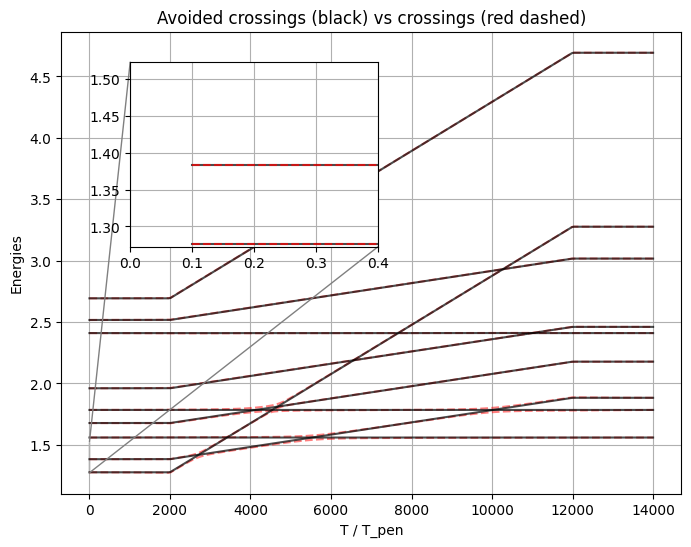

In [2]:

memory = joblib.Memory(location=".joblib_cache", verbose=0)
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
@memory.cache
def all_move_sequences(N):
    moves = (1, 0, -1)
    return list(itertools.product(moves, repeat=N))


def normalize(vec):
    return vec / np.sum(vec) if np.sum(vec) != 0 else vec


@memory.cache
def avoided(n, Ts):
    eigvals = []
    eigvecs = []
    HB = H_B(n)
    HP = H_P(n)
    HX = H_D(n, X)

    for t in Ts:
        H = HB + b(t) * HP + a(t) * HX
        vals, vecs = np.linalg.eigh(H)
        eigvals.append(vals)
        eigvecs.append(vecs)

    return np.array(eigvals), np.array(eigvecs)


@memory.cache
def crossings(n, Ts):
    eigvals = []
    eigvecs = []
    HB = H_B(n)
    HP = H_P(n)

    for t in Ts:
        H = HB + b(t) * HP
        vals, vecs = np.linalg.eigh(H)
        eigvals.append(vals)
        eigvecs.append(vecs)

    return np.array(eigvals), np.array(eigvecs)


eigvals_avoided, eigvecs_avoided = avoided(n, Ts)
eigvals_crossing, eigvecs_crossing = crossings(n, Ts)

t_scaled = Ts

fig, ax = plt.subplots(figsize=(8, 6))

# Main plot
for i in range(eigvals_avoided.shape[1]):
    ax.plot(t_scaled, eigvals_avoided[:, i], "r--", alpha=0.5)

for i in range(eigvals_crossing.shape[1]):
    ax.plot(t_scaled, eigvals_crossing[:, i], color="black", alpha=0.7)

#ax.set_xlim(0, 1)
ax.set_xlabel("T / T_pen")
ax.set_ylabel("Energies")
ax.set_title("Avoided crossings (black) vs crossings (red dashed)")
ax.grid()

axins = inset_axes(
    ax,
    width="40%",
    height="40%",
    loc="upper left",
    bbox_to_anchor=(0.1, -0.05, 1, 1),  # shift slightly inward
    bbox_transform=ax.transAxes,
    #borderpad=1.5  # extra spacing from edges
)

for i in range(eigvals_avoided.shape[1]):
    axins.plot(t_scaled, eigvals_avoided[:, i], color="black", alpha=0.7)

for i in range(eigvals_crossing.shape[1]):
    axins.plot(t_scaled, eigvals_crossing[:, i], "r--", alpha=0.7)

x1, x2 = 0, 0.4
y1, y2 = np.min(eigvals_avoided), np.min(eigvals_avoided) + 0.25

axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.grid()
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")
plt.savefig("LZ-plot.pdf")
plt.show()

100%|███████████████████████████████████████████████████████████████████████████████████████████| 491/491 [00:06<00:00, 72.96it/s]


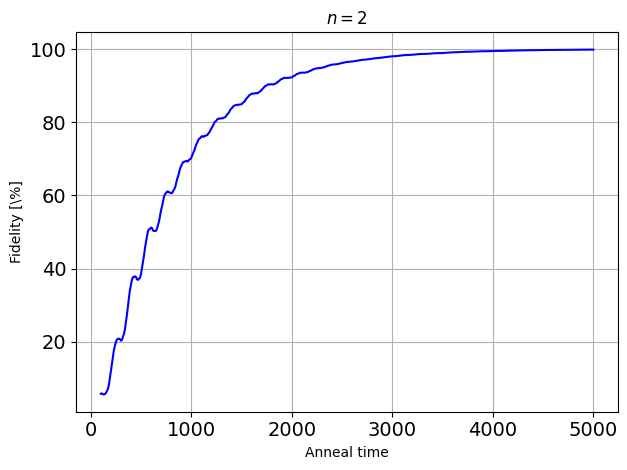

In [3]:
from matplotlib.ticker import PercentFormatter

n = 2
beta_max = 1 / n
alpha_max = 0.05 / n
explore_fraction = 1 / 5
n_steps = 5000

T_pen_vec = np.arange(100, 5001, 10)  # matches MATLAB 100:10:5000 → 491 points
fidelities = []

cost_vec = np.diagonal(H_B(n))
pen_vec = np.diagonal(H_P(n))
gs_idx = np.argmin(cost_vec + beta_max * pen_vec)

for t in tqdm.tqdm(T_pen_vec):
    T_x = t * explore_fraction  # matches TmaxExplore = TimePen * ExploreFraction
    psi = schrodinger_split(
        T_pen=t,
        n=n,
        T_x=T_x,
        alpha_max=alpha_max,
        beta_max=beta_max,
        n_steps=n_steps,
    )
    fidelities.append(np.abs(psi[gs_idx])**2)

plt.figure()
plt.plot(T_pen_vec, np.array(fidelities) * 100, 'b-', linewidth=1.5)
plt.xlabel("Anneal time")
plt.ylabel("Fidelity [\\%]")
plt.title(f"$n={n}$")
plt.grid(True)
plt.gca().tick_params(labelsize=14)
plt.tight_layout()
plt.savefig("python.pdf")
plt.show()

ValueError: x and y must have same first dimension, but have shapes (1,) and (491,)

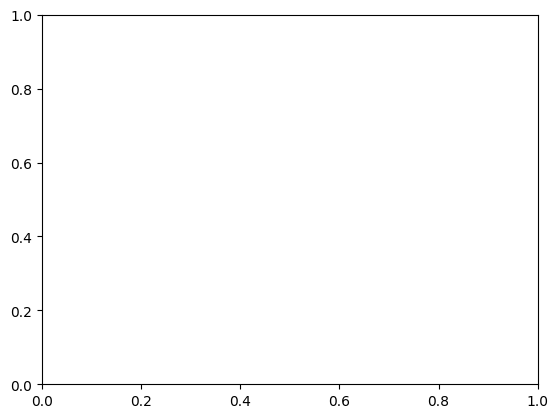

In [4]:
from matplotlib.ticker import PercentFormatter

plt.figure()
plt.plot(T_pen, fidelities)
plt.xlabel("Anneal time")
plt.ylabel("Fidelity (%)")

ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.grid(True, which="both")
plt.show()
plt.savefig(f"{n}.pdf")